## <h3 align="center"> __Johns Hopkins University__</h3>
## <h3 align="center">__Whiting School of Engineering__</h3>
## <h3 align="center">__Engineering for Professionals__</h3>
## <h3 align="center">__685.801 Data Science: Independent Study__</h3>
## <h3 align="center">__Test Set Model Validation__</h3>

---

- **Purpose:** Load trained checkpoints from `./models`, evaluate every model on the held-out test set, and save each evaluation to `test_{model_name}.json`.
- **Primary test metrics:** `Test Micro F1`, `Test Macro F1`, and `Test Weighted F1`.
- **Additional analysis:** backbone-level summaries, paired backbone deltas, bootstrap pairwise model comparisons, and separate figures.
- **How to use:**
  1. Run the notebook top to bottom.
  2. In Colab, the notebook will mount Google Drive for results output and clone the GitHub repo to access `./models` automatically.
  3. Review the saved JSON outputs, summary tables, bootstrap comparisons, and figures.

---

In [1]:
%pip install numpy pandas scipy seaborn matplotlib scikit-learn statsmodels kagglehub torch torchvision torchao torchmetrics

In [2]:
# Environment check
import sys, platform
print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
try:
    import numpy as np, pandas as pd, scipy, seaborn, matplotlib, sklearn, statsmodels, torch, torchvision, kagglehub
    print(f'numpy:      {np.__version__}')
    print(f'pandas:     {pd.__version__}')
    print(f'scipy:      {scipy.__version__}')
    print(f'seaborn:    {seaborn.__version__}')
    print(f'matplotlib: {matplotlib.__version__}')
    print(f'sklearn:    {sklearn.__version__}')
    print(f'statsmodels:{statsmodels.__version__}')
    print(f'torch:      {torch.__version__}')
    print(f'torchvision:{torchvision.__version__}')
    print(f'kagglehub:  {kagglehub.__version__}')
except Exception as exc:
    print('Optional packages missing or version check failed:', exc)
    print('Use the command in the cell above to install necessary packages.')

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
numpy:      2.0.2
pandas:     2.2.2
scipy:      1.16.3
seaborn:    0.13.2
matplotlib: 3.10.0
sklearn:    1.6.1
statsmodels:0.14.6
torch:      2.11.0+cu128
torchvision:0.26.0+cu128
kagglehub:  1.0.2


In [3]:
import os
import subprocess
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

REPO_URL = "https://github.com/ddimpfel/JHU_IS_26.git"
REPO_NAME = REPO_URL.split("/")[-1].replace(".git", "")

if IN_COLAB:
    drive.mount('/content/drive')
    repo_root = Path('/content') / REPO_NAME
    if not repo_root.exists():
        subprocess.run(['git', 'clone', REPO_URL], check=True)
    CURRENT_WORK_DIR = repo_root
    os.chdir(CURRENT_WORK_DIR)
    RESULTS_DIR = Path('/content/drive/MyDrive/is26_models/joint_embedding_results')
else:
    CURRENT_WORK_DIR = Path.cwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import json
import re
import random
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from IPython.display import display
from PIL import Image
from scipy.stats import wilcoxon
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.stats.multitest import multipletests
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader, Dataset

from continual_learning import CILComputerVisionModel, bootstrap_performance_diff
from gre_model_base import GeneralistRouterExperts, cost_proxy, expected_calibration_error, expert_metrics, router_entropy
from joint_embedding import JointEmbeddingModule

## Config

In [5]:
SEED = 7
NUM_WORKERS = 0
PIN_MEMORY = bool(IN_COLAB)
PERSIST_WORKERS = False
TOTAL_CLASSES = 9
IMG_SIZE = 224
BATCH_SIZE = 64 if IN_COLAB else 8
NUM_TASKS = 3
BS_RESAMPLES = 1000
USE_CLASS_MASKING = True

NUM_EXPERTS = 6
HIDDEN_EXPERT_SIZE = 128
DROPOUT = 0.1
TOP_K = 2
LAMBDA_AUX = 0.05
TFE_D_MODEL = 32
TFE_NHEAD = 4

JE_EMBEDDING_DIM = 256
JE_PROJECTION_DIM = 256
JE_FEATURE_KEY = 'projections'
JE_TEMPERATURE = 0.07

MODELS_DIR = CURRENT_WORK_DIR / 'models'
TEST_RESULTS_DIR = (
    Path('/content/drive/MyDrive/is26_models/test_results')
    if IN_COLAB else CURRENT_WORK_DIR / 'results' / 'test'
)
BACKBONE_ORDER = ['MobileNet', 'ConvNeXt', 'JE MobileNet', 'JE ConvNeXt']
BASELINE_BACKBONE = 'MobileNet'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'
np_rng = np.random.default_rng(seed=SEED)
tor_gen = torch.Generator(device='cpu').manual_seed(SEED)

if str(CURRENT_WORK_DIR) not in sys.path:
    sys.path.insert(0, str(CURRENT_WORK_DIR))

TEST_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Using device: {device}')
print(f'IN_COLAB={IN_COLAB}')
print(f'CURRENT_WORK_DIR={CURRENT_WORK_DIR}')
print(f'MODELS_DIR={MODELS_DIR.resolve()}')
print(f'TEST_RESULTS_DIR={TEST_RESULTS_DIR.resolve()}')

Using device: cuda
IN_COLAB=True
CURRENT_WORK_DIR=/content/JHU_IS_26
MODELS_DIR=/content/JHU_IS_26/models
TEST_RESULTS_DIR=/content/drive/MyDrive/is26_models/test_results


## Test Data Loading

In [6]:
GTSRB_DATASET_NAME = 'meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'
csv_paths = {
    'train.csv': None,
    'test.csv': None,
    'meta.csv': None,
}

download_dir = Path(kagglehub.dataset_download(GTSRB_DATASET_NAME))
for csv in download_dir.rglob('*.csv'):
    if csv.name.lower() in csv_paths:
        csv_paths[csv.name.lower()] = csv

train_csv = pd.read_csv(str(csv_paths['train.csv']))
train_df, val_df = train_test_split(
    train_csv,
    test_size=0.2,
    shuffle=True,
    stratify=train_csv.ClassId,
    random_state=SEED,
)
test_df = pd.read_csv(str(csv_paths['test.csv']))

prohibitory_sign_classes = [i for i in range(1, 11)]
prohibitory_sign_classes.remove(6)

prohib_train_df = train_df[train_df.ClassId.isin(prohibitory_sign_classes)].reset_index(drop=True)
prohib_test_df = test_df[test_df.ClassId.isin(prohibitory_sign_classes)].reset_index(drop=True)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(prohibitory_sign_classes),
    y=prohib_train_df.ClassId.values,
)
class_weights_dict = dict(zip(prohibitory_sign_classes, weights))
weights_tensor = torch.tensor(list(class_weights_dict.values()), dtype=torch.float, device=device)
class_mapping = {raw_id: i for i, raw_id in enumerate(sorted(prohibitory_sign_classes))}

print('Kaggle dataset directory:', download_dir)
print(f'Test examples: {len(prohib_test_df)}')

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Kaggle dataset directory: /kaggle/input/gtsrb-german-traffic-sign
Test examples: 5250


In [7]:
class TrafficSignDataset(Dataset):
    def __init__(self, data_dir, image_file_paths, targets, transformer, class_mapping):
        if len(targets) != len(image_file_paths):
            raise AssertionError('Must have equal number of labels to images')

        self.data_dir = data_dir
        self.image_file_paths = list(image_file_paths)
        self.targets = list(targets)
        self.transformer = transformer
        self.class_mapping = class_mapping

    def __len__(self):
        return len(self.image_file_paths)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.image_file_paths[idx])
        image = Image.open(img_path).convert('RGB')
        transformed_img = self.transformer(image)
        label = self.class_mapping[self.targets[idx]]
        target = {'label': torch.tensor(label, dtype=torch.long)}
        return transformed_img, target, str(img_path)


def collate_data(return_values):
    images = [item[0] for item in return_values]
    targets = [item[1] for item in return_values]
    paths = [item[2] for item in return_values]
    return images, targets, paths


transform_pipeline = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_dataset = TrafficSignDataset(
    download_dir,
    prohib_test_df.Path,
    prohib_test_df.ClassId,
    transform_pipeline,
    class_mapping,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=collate_data,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSIST_WORKERS,
    generator=tor_gen,
)

loss_fn = CrossEntropyLoss(weight=weights_tensor)
print(f'Test dataloader batches: {len(test_dataloader)}')

Test dataloader batches: 83


## Model Reconstruction

In [8]:
class MobileNetGeneralist(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base_model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        self.backbone = base_model.features
        self.pool = base_model.avgpool
        self.out_channels = base_model.classifier[0].in_features
        self.classifier = nn.Sequential(
            nn.Linear(self.out_channels, num_classes),
            nn.LayerNorm(num_classes),
        )

    def forward(self, x, return_features=False):
        x = self.backbone(x)
        features = self.pool(x).flatten(1)
        logits = self.classifier(features)
        if return_features:
            return logits, features
        return logits


class ConvNeXtTinyGeneralist(nn.Module):
    def __init__(self, num_classes, weights=models.ConvNeXt_Tiny_Weights.DEFAULT, dropout=0.1):
        super().__init__()
        base_model = models.convnext_tiny(weights=weights)
        self.backbone = base_model.features
        self.pool = base_model.avgpool
        self.out_channels = base_model.classifier[2].in_features
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.out_channels),
            nn.Dropout(dropout),
            nn.Linear(self.out_channels, num_classes),
        )

    def forward(self, x, return_features=False):
        x = self.backbone(x)
        features = self.pool(x).flatten(1)
        logits = self.classifier(features)
        if return_features:
            return logits, features
        return logits


class MlpRouter(nn.Module):
    def __init__(self, input_size, num_experts):
        super().__init__()
        self.num_experts = num_experts
        self.gating = nn.Linear(input_size, num_experts, bias=False)

    def forward(self, x):
        logits = self.gating(x)
        if self.training:
            logits = logits + torch.randn_like(logits) * (1.0 / self.num_experts)
        return logits


class LayeredRouter(nn.Module):
    def __init__(self, input_size, num_experts):
        super().__init__()
        self.num_experts = num_experts
        self.ff1 = nn.Linear(input_size, input_size * 2)
        self.ff2 = nn.Linear(input_size * 2, num_experts, bias=False)

    def forward(self, x):
        logits = self.ff2(self.ff1(x))
        if self.training:
            logits = logits + torch.randn_like(logits) * (1.0 / self.num_experts)
        return logits


class MlpExpert(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x):
        return self.network(x)


class TransformerExpert(nn.Module):
    def __init__(self, in_features, d_model, nhead, output_size):
        super().__init__()
        if in_features % d_model != 0:
            raise ValueError('d_model must perfectly divide in_features')
        self.num_patches = in_features // d_model
        self.d_model = d_model
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, d_model))
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True),
            num_layers=1,
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, output_size),
        )

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.view(batch_size, self.num_patches, self.d_model)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1) + self.pos_embed
        x = self.transformer(x)
        cls_output = x[:, 0, :]
        return self.classifier(cls_output)


class ResidualGatedMlpExpert(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.LayerNorm(input_size),
            nn.Linear(input_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.block1 = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, hidden_size * 2),
            nn.GLU(dim=1),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, hidden_size * 2),
            nn.GLU(dim=1),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.input_proj(x)
        x = x + self.block1(x)
        x = x + self.block2(x)
        return self.classifier(x)


class JointEmbeddingRouterExperts(GeneralistRouterExperts):
    def __init__(self, *args, feature_key='projections', **kwargs):
        super().__init__(*args, **kwargs)
        self.feature_key = feature_key
        self._last_joint_embedding_outputs = None

    def reset_routing_state(self):
        super().reset_routing_state()
        self._last_joint_embedding_outputs = None

    def get_joint_embedding_loss(self, labels):
        if self._last_joint_embedding_outputs is None:
            param = next(self.parameters())
            return torch.zeros((), device=param.device, dtype=param.dtype)

        if self.feature_key == 'embeddings':
            return self.generalist.compute_contrastive_loss(
                labels=labels,
                embeddings=self._last_joint_embedding_outputs['embeddings'],
            )

        return self.generalist.compute_contrastive_loss(
            labels=labels,
            projections=self._last_joint_embedding_outputs['projections'],
        )

    def forward(self, x):
        encoded = self.generalist.backbone.encode(x)
        generalist_logits = encoded['logits']
        features = encoded[self.feature_key]
        if features.ndim != 2:
            features = torch.flatten(features, 1)

        router_logits = self.router(features)
        router_probs = F.softmax(router_logits, dim=1)
        topk_probs, topk_indices = torch.topk(router_probs, k=self.k, dim=1)
        topk_weights = topk_probs / topk_probs.sum(dim=1, keepdim=True).clamp_min(1e-8)

        experts_logits = torch.zeros_like(generalist_logits, device=features.device, dtype=features.dtype)
        for expert_idx, expert in enumerate(self.experts):
            selected_rows, selected_slots = torch.where(topk_indices == expert_idx)
            if selected_rows.numel() == 0:
                continue
            expert_features = features[selected_rows]
            expert_logits = expert(expert_features)
            expert_weights = topk_weights[selected_rows, selected_slots].unsqueeze(1)
            experts_logits[selected_rows] += expert_logits * expert_weights

        self._last_router_probs = router_probs.detach()
        self._last_topk_indices = topk_indices.detach()
        self._last_aux_loss = self._compute_auxiliary_loss(router_probs, topk_indices)
        self._last_joint_embedding_outputs = {
            key: value
            for key, value in encoded.items()
            if isinstance(value, torch.Tensor)
        }
        return (generalist_logits + experts_logits) / self.temperature


def strip_trailing_date_suffix(value):
    return re.sub(r'_\d{4}-\d{2}-\d{2}$', '', str(value))


def extract_model_name(checkpoint_path: Path):
    return strip_trailing_date_suffix(checkpoint_path.stem)


def build_expert_factory(expert_name, generalist_out_dim):
    def expert_factory():
        if expert_name == 'MLP Experts':
            return MlpExpert(
                input_size=generalist_out_dim,
                hidden_size=HIDDEN_EXPERT_SIZE,
                output_size=TOTAL_CLASSES,
                dropout=DROPOUT,
            )
        if expert_name == 'Transformer Experts':
            return TransformerExpert(
                in_features=generalist_out_dim,
                d_model=TFE_D_MODEL,
                nhead=TFE_NHEAD,
                output_size=TOTAL_CLASSES,
            )
        if expert_name == 'ResMLP Experts':
            return ResidualGatedMlpExpert(
                input_size=generalist_out_dim,
                hidden_size=HIDDEN_EXPERT_SIZE,
                output_size=TOTAL_CLASSES,
                dropout=DROPOUT,
            )
        raise KeyError(f'Unknown expert: {expert_name}')

    return expert_factory


def build_model_from_name(model_name: str):
    parts = str(model_name).split(' + ')
    if len(parts) != 3:
        raise ValueError(f'Expected model name in the form Generalist + Router + Expert, got: {model_name}')

    generalist_name, router_name, expert_name = parts

    if generalist_name == 'MobileNet':
        generalist = MobileNetGeneralist(num_classes=TOTAL_CLASSES)
        generalist_out_dim = generalist.out_channels
        router_cls = MlpRouter if router_name == 'MLP Router' else LayeredRouter
        router = router_cls(input_size=generalist_out_dim, num_experts=NUM_EXPERTS)
        return GeneralistRouterExperts(
            generalist=generalist,
            router=router,
            expert_factory=build_expert_factory(expert_name, generalist_out_dim),
            num_experts=NUM_EXPERTS,
            num_classes=TOTAL_CLASSES,
            k=TOP_K,
            lambda_aux=LAMBDA_AUX,
        )

    if generalist_name == 'ConvNeXt':
        generalist = ConvNeXtTinyGeneralist(num_classes=TOTAL_CLASSES)
        generalist_out_dim = generalist.out_channels
        router_cls = MlpRouter if router_name == 'MLP Router' else LayeredRouter
        router = router_cls(input_size=generalist_out_dim, num_experts=NUM_EXPERTS)
        return GeneralistRouterExperts(
            generalist=generalist,
            router=router,
            expert_factory=build_expert_factory(expert_name, generalist_out_dim),
            num_experts=NUM_EXPERTS,
            num_classes=TOTAL_CLASSES,
            k=TOP_K,
            lambda_aux=LAMBDA_AUX,
        )

    if generalist_name == 'JE MobileNet Small':
        generalist = JointEmbeddingModule(
            num_classes=TOTAL_CLASSES,
            backbone='mobilenet_v3_small',
            embedding_dim=JE_EMBEDDING_DIM,
            projection_dim=JE_PROJECTION_DIM,
            pretrained=True,
            temperature=JE_TEMPERATURE,
        )
        generalist_out_dim = JE_PROJECTION_DIM if JE_FEATURE_KEY == 'projections' else JE_EMBEDDING_DIM
        router_cls = MlpRouter if router_name == 'MLP Router' else LayeredRouter
        router = router_cls(input_size=generalist_out_dim, num_experts=NUM_EXPERTS)
        return JointEmbeddingRouterExperts(
            generalist=generalist,
            router=router,
            expert_factory=build_expert_factory(expert_name, generalist_out_dim),
            num_experts=NUM_EXPERTS,
            num_classes=TOTAL_CLASSES,
            k=TOP_K,
            lambda_aux=LAMBDA_AUX,
            feature_key=JE_FEATURE_KEY,
        )

    if generalist_name == 'JE ConvNeXt Tiny':
        generalist = JointEmbeddingModule(
            num_classes=TOTAL_CLASSES,
            backbone='convnext_tiny',
            embedding_dim=JE_EMBEDDING_DIM,
            projection_dim=JE_PROJECTION_DIM,
            pretrained=True,
            temperature=JE_TEMPERATURE,
        )
        generalist_out_dim = JE_PROJECTION_DIM if JE_FEATURE_KEY == 'projections' else JE_EMBEDDING_DIM
        router_cls = MlpRouter if router_name == 'MLP Router' else LayeredRouter
        router = router_cls(input_size=generalist_out_dim, num_experts=NUM_EXPERTS)
        return JointEmbeddingRouterExperts(
            generalist=generalist,
            router=router,
            expert_factory=build_expert_factory(expert_name, generalist_out_dim),
            num_experts=NUM_EXPERTS,
            num_classes=TOTAL_CLASSES,
            k=TOP_K,
            lambda_aux=LAMBDA_AUX,
            feature_key=JE_FEATURE_KEY,
        )

    raise KeyError(f'Unsupported generalist name: {generalist_name}')

In [9]:
def to_json_compatible(value):
    if isinstance(value, dict):
        return {str(key): to_json_compatible(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_json_compatible(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    return value


def add_model_component_columns(df: pd.DataFrame):
    if 'Model' not in df.columns:
        raise KeyError("Expected a 'Model' column in the comparison dataframe.")

    parts = df['Model'].astype(str).str.split(r'\s+\+\s+', expand=True)
    if parts.shape[1] < 3:
        raise ValueError("Expected model names in the form 'Generalist + Router + Expert'.")

    out = df.copy()
    out['Generalist'] = parts[0]
    out['Router'] = parts[1]
    out['Expert'] = parts[2]
    return out


def normalize_backbone_label(generalist_name: str):
    name = str(generalist_name).strip()
    lowered = name.lower()
    if lowered.startswith('je mobilenet'):
        return 'JE MobileNet'
    if lowered.startswith('je convnext'):
        return 'JE ConvNeXt'
    if lowered.startswith('mobilenet'):
        return 'MobileNet'
    if lowered.startswith('convnext'):
        return 'ConvNeXt'
    return np.nan


def flatten_multiindex_columns(df: pd.DataFrame):
    flattened = []
    for col in df.columns:
        if isinstance(col, tuple):
            flattened.append(' '.join(str(part) for part in col if part).strip())
        else:
            flattened.append(str(col))
    result = df.copy()
    result.columns = flattened
    return result


def summarize_component_performance(df: pd.DataFrame, component_col: str, metrics: list[str]):
    available_metrics = [metric for metric in metrics if metric in df.columns]
    if not available_metrics:
        return pd.DataFrame()

    summary = df.groupby(component_col)[available_metrics].agg(['mean']).reset_index()
    summary = flatten_multiindex_columns(summary)
    sort_column = f'{available_metrics[0]} mean'
    if sort_column in summary.columns:
        summary = summary.sort_values(sort_column, ascending=False).reset_index(drop=True)
    return summary


def build_component_delta_table(df: pd.DataFrame, component_col: str, baseline_name: str, compare_names: list[str], fixed_cols: list[str], metrics: list[str]):
    available_metrics = [metric for metric in metrics if metric in df.columns]
    if not available_metrics:
        return pd.DataFrame()

    rows = []
    for compare_name in compare_names:
        subset = df[df[component_col].isin([baseline_name, compare_name])].copy()
        if subset[component_col].nunique() < 2:
            continue

        pivot = subset.pivot_table(index=fixed_cols, columns=component_col, values=available_metrics, aggfunc='first')
        if baseline_name not in pivot.columns.get_level_values(1):
            continue
        if compare_name not in pivot.columns.get_level_values(1):
            continue

        delta_df = pd.DataFrame(index=pivot.index).reset_index()
        delta_df[component_col] = compare_name
        for metric in available_metrics:
            baseline_key = (metric, baseline_name)
            compare_key = (metric, compare_name)
            if baseline_key not in pivot.columns or compare_key not in pivot.columns:
                continue
            baseline_values = pivot[baseline_key].to_numpy()
            compare_values = pivot[compare_key].to_numpy()
            delta_df[f'{metric} [{baseline_name}]'] = baseline_values
            delta_df[f'{metric} [{compare_name}]'] = compare_values
            delta_df[f'{metric} Delta ({compare_name} - {baseline_name})'] = compare_values - baseline_values

        rows.append(delta_df)

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


def run_paired_component_tests(df: pd.DataFrame, component_col: str, baseline_name: str, compare_names: list[str], fixed_cols: list[str], metrics: list[str]):
    available_metrics = [metric for metric in metrics if metric in df.columns]
    if not available_metrics:
        return pd.DataFrame()

    rows = []
    raw_p_values = []
    p_value_row_indices = []

    for compare_name in compare_names:
        subset = df[df[component_col].isin([baseline_name, compare_name])].copy()
        if subset[component_col].nunique() < 2:
            continue

        pivot = subset.pivot_table(index=fixed_cols, columns=component_col, values=available_metrics, aggfunc='first')
        if baseline_name not in pivot.columns.get_level_values(1):
            continue
        if compare_name not in pivot.columns.get_level_values(1):
            continue

        for metric in available_metrics:
            baseline_key = (metric, baseline_name)
            compare_key = (metric, compare_name)
            if baseline_key not in pivot.columns or compare_key not in pivot.columns:
                continue

            paired = pivot[[baseline_key, compare_key]].dropna()
            if paired.empty:
                continue

            baseline_values = paired[baseline_key].to_numpy(dtype=float)
            compare_values = paired[compare_key].to_numpy(dtype=float)
            deltas = compare_values - baseline_values
            nonzero_deltas = deltas[~np.isclose(deltas, 0.0)]

            p_value = np.nan
            test_name = 'Wilcoxon signed-rank'
            if len(nonzero_deltas) == 0:
                p_value = 1.0
                test_name = 'All deltas are zero'
            elif len(nonzero_deltas) >= 2:
                try:
                    _, p_value = wilcoxon(nonzero_deltas, alternative='two-sided', zero_method='wilcox')
                except ValueError:
                    p_value = np.nan
                    test_name = 'Wilcoxon unavailable'
            else:
                test_name = 'Insufficient non-zero pairs'

            row = {
                component_col: compare_name,
                'Metric': metric,
                'Paired Configurations': len(deltas),
                f'Mean {baseline_name}': baseline_values.mean(),
                f'Mean {compare_name}': compare_values.mean(),
                'Mean Delta': deltas.mean(),
                'Median Delta': np.median(deltas),
                'Std Delta': deltas.std(ddof=0),
                'Raw P Value': p_value,
                'Test': test_name,
            }
            rows.append(row)
            if not np.isnan(p_value):
                raw_p_values.append(p_value)
                p_value_row_indices.append(len(rows) - 1)

    if not rows:
        return pd.DataFrame()

    result = pd.DataFrame(rows)
    result['FDR BH P Value'] = np.nan
    result['Significant @ 0.05'] = False
    if raw_p_values:
        _, corrected, _, _ = multipletests(raw_p_values, method='fdr_bh')
        for row_index, corrected_p in zip(p_value_row_indices, corrected):
            result.loc[row_index, 'FDR BH P Value'] = corrected_p
            result.loc[row_index, 'Significant @ 0.05'] = bool(corrected_p < 0.05)

    return result.sort_values([component_col, 'Metric']).reset_index(drop=True)


def style_component_table(df: pd.DataFrame):
    if df.empty:
        return df

    formatters = {}
    for column in df.columns:
        if pd.api.types.is_numeric_dtype(df[column]):
            if 'count' in column.lower() or 'paired configurations' in column.lower():
                formatters[column] = '{:.0f}'
            elif 'Cost Proxy' in column or 'Num Parameters' in column:
                formatters[column] = '{:.0f}'
            else:
                formatters[column] = '{:.4f}'

    return df.style.format(formatters)


def collect_test_gre_metrics(cil_model, eval_dataloader, num_classes=TOTAL_CLASSES, device=device):
    model = cil_model.model
    if not isinstance(model, GeneralistRouterExperts):
        return {}

    entropy_metrics = router_entropy(model, eval_dataloader, device=device)
    expert_summary = expert_metrics(model, eval_dataloader, device=device)
    ece = expected_calibration_error(
        model,
        num_classes=num_classes,
        val_data=eval_dataloader,
        device=device,
    )
    params = model.get_model_parameters_by_component()
    expected_calls = expert_summary['Expected Expert Calls']

    return {
        'Test Router Entropy': entropy_metrics['Mean Router Entropy'],
        'Test Normalized Router Entropy': entropy_metrics['Normalized Router Entropy'],
        'Test Router Entropy Std': entropy_metrics['Std Router Entropy'],
        'Test Avg Router Prob': entropy_metrics['Avg Router Prob'],
        'Test ECE': ece,
        'Test Expected Expert Calls': expected_calls,
        'Test Expert Utilization Ratio': expert_summary['Expert Selection Ratio'],
        'Test Cost Proxy': cost_proxy(expected_calls, params),
    }


def evaluate_checkpoint(checkpoint_path: Path):
    model_name = extract_model_name(checkpoint_path)
    model_instance = build_model_from_name(model_name)
    cil_model = CILComputerVisionModel.load(model_instance, filename=str(checkpoint_path), device=device)
    cil_model.model.to(device)
    test_loss, test_metrics = cil_model.evaluate(test_dataloader, loss_fn, apply_class_masking=USE_CLASS_MASKING)

    result = {
        'Model': model_name,
        'Source Checkpoint': str(checkpoint_path),
        'Test Loss': test_loss,
        'Test Macro F1': test_metrics['Macro F1'],
        'Test Micro F1': test_metrics['Micro F1'],
        'Test Weighted F1': test_metrics['Weighted F1'],
        'Num Parameters': sum(parameter.numel() for parameter in cil_model.model.parameters()),
    }
    result.update(collect_test_gre_metrics(cil_model, test_dataloader, device=device))

    output_path = TEST_RESULTS_DIR / f'test_{model_name}.json'
    with output_path.open('w', encoding='utf-8') as handle:
        json.dump(to_json_compatible(result), handle, indent=4)

    return result, cil_model, output_path

## Load and Evaluate Checkpoints

In [10]:
checkpoint_paths = sorted(MODELS_DIR.glob('*.pth'))
if not checkpoint_paths:
    raise FileNotFoundError(f'No .pth checkpoints were found in {MODELS_DIR.resolve()}')

pd.DataFrame({
    'Checkpoint File': [path.name for path in checkpoint_paths],
    'Model Name': [extract_model_name(path) for path in checkpoint_paths],
})

,Checkpoint File,Model Name
0,ConvNeXt + Layered Router + MLP Experts_2026-0...,ConvNeXt + Layered Router + MLP Experts
1,ConvNeXt + Layered Router + ResMLP Experts_202...,ConvNeXt + Layered Router + ResMLP Experts
2,ConvNeXt + Layered Router + Transformer Expert...,ConvNeXt + Layered Router + Transformer Experts
3,ConvNeXt + MLP Router + MLP Experts_2026-06-28...,ConvNeXt + MLP Router + MLP Experts
4,ConvNeXt + MLP Router + ResMLP Experts_2026-06...,ConvNeXt + MLP Router + ResMLP Experts
5,ConvNeXt + MLP Router + Transformer Experts_20...,ConvNeXt + MLP Router + Transformer Experts
6,JE ConvNeXt Tiny + Layered Router + MLP Expert...,JE ConvNeXt Tiny + Layered Router + MLP Experts
7,JE ConvNeXt Tiny + Layered Router + ResMLP Exp...,JE ConvNeXt Tiny + Layered Router + ResMLP Exp...
8,JE ConvNeXt Tiny + Layered Router + Transforme...,JE ConvNeXt Tiny + Layered Router + Transforme...
9,JE ConvNeXt Tiny + MLP Router + MLP Experts_20...,JE ConvNeXt Tiny + MLP Router + MLP Experts


In [11]:
test_results = []
loaded_wrappers = {}
loaded_models = {}
saved_test_json_paths = []

for checkpoint_path in checkpoint_paths:
    print(f'Evaluating {checkpoint_path.name}...')
    result, cil_model, output_path = evaluate_checkpoint(checkpoint_path)
    test_results.append(result)
    loaded_wrappers[result['Model']] = cil_model
    loaded_models[result['Model']] = cil_model.model
    saved_test_json_paths.append(output_path)

test_results_df = pd.DataFrame(test_results)
test_results_df

Evaluating ConvNeXt + Layered Router + MLP Experts_2026-06-28.pth...
Evaluating ConvNeXt + Layered Router + ResMLP Experts_2026-06-28.pth...
Evaluating ConvNeXt + Layered Router + Transformer Experts_2026-06-28.pth...
Evaluating ConvNeXt + MLP Router + MLP Experts_2026-06-28.pth...
Evaluating ConvNeXt + MLP Router + ResMLP Experts_2026-06-28.pth...
Evaluating ConvNeXt + MLP Router + Transformer Experts_2026-06-28.pth...
Evaluating JE ConvNeXt Tiny + Layered Router + MLP Experts_2026-07-15.pth...
Evaluating JE ConvNeXt Tiny + Layered Router + ResMLP Experts_2026-07-15.pth...
Evaluating JE ConvNeXt Tiny + Layered Router + Transformer Experts_2026-07-15.pth...
Evaluating JE ConvNeXt Tiny + MLP Router + MLP Experts_2026-07-15.pth...
Evaluating JE ConvNeXt Tiny + MLP Router + ResMLP Experts_2026-07-15.pth...
Evaluating JE ConvNeXt Tiny + MLP Router + Transformer Experts_2026-07-15.pth...
Evaluating JE MobileNet Small + Layered Router + MLP Experts_2026-07-15.pth...
Downloading: "https://dow

100%|██████████| 9.83M/9.83M [00:00<00:00, 204MB/s]


Evaluating JE MobileNet Small + Layered Router + ResMLP Experts_2026-07-15.pth...
Evaluating JE MobileNet Small + Layered Router + Transformer Experts_2026-07-15.pth...
Evaluating JE MobileNet Small + MLP Router + MLP Experts_2026-07-15.pth...
Evaluating JE MobileNet Small + MLP Router + ResMLP Experts_2026-07-15.pth...
Evaluating JE MobileNet Small + MLP Router + Transformer Experts_2026-07-15.pth...
Evaluating MobileNet + Layered Router + MLP Experts_2026-06-28.pth...
Evaluating MobileNet + Layered Router + ResMLP Experts_2026-06-28.pth...
Evaluating MobileNet + Layered Router + Transformer Experts_2026-06-28.pth...
Evaluating MobileNet + MLP Router + MLP Experts_2026-06-28.pth...
Evaluating MobileNet + MLP Router + ResMLP Experts_2026-06-28.pth...
Evaluating MobileNet + MLP Router + Transformer Experts_2026-06-28.pth...


,Model,Source Checkpoint,Test Loss,Test Macro F1,Test Micro F1,Test Weighted F1,Num Parameters,Test Router Entropy,Test Normalized Router Entropy,Test Router Entropy Std,Test Avg Router Prob,Test ECE,Test Expected Expert Calls,Test Expert Utilization Ratio,Test Cost Proxy
0,ConvNeXt + Layered Router + MLP Experts,/content/JHU_IS_26/models/ConvNeXt + Layered R...,0.248125,0.927948,0.931238,0.931917,29615008,0.132005,0.073673,0.271071,"[0.38820693, 0.26997885, 0.08834664, 0.221782,...",0.005118,2.0,"[0.21847619, 0.15238096, 0.13409524, 0.1206666...",30212565.0
1,ConvNeXt + Layered Router + ResMLP Experts,/content/JHU_IS_26/models/ConvNeXt + Layered R...,0.350458,0.882669,0.881524,0.883451,30023584,0.040029,0.022341,0.136510,"[0.15705507, 0.399763, 0.22915994, 0.011144331...",0.024669,2.0,"[0.13914286, 0.23514286, 0.18990476, 0.0891428...",31029717.0
2,ConvNeXt + Layered Router + Transformer Experts,/content/JHU_IS_26/models/ConvNeXt + Layered R...,0.374480,0.875154,0.895238,0.890174,29849632,0.757926,0.423007,0.674511,"[0.1947033, 0.061476793, 0.33624896, 0.0642847...",0.035716,2.0,"[0.1427619, 0.046761904, 0.30180952, 0.1104761...",30681813.0
3,ConvNeXt + MLP Router + MLP Experts,/content/JHU_IS_26/models/ConvNeXt + MLP Route...,0.277397,0.929924,0.929905,0.931253,28429216,1.514398,0.845201,0.518350,"[0.16598292, 0.2140697, 0.12732653, 0.13861781...",0.016880,2.0,"[0.22761905, 0.15466666, 0.13485715, 0.1090476...",29026773.0
4,ConvNeXt + MLP Router + ResMLP Experts,/content/JHU_IS_26/models/ConvNeXt + MLP Route...,0.391194,0.880430,0.881143,0.881533,28837792,1.248926,0.697039,0.582758,"[0.107934214, 0.21591327, 0.12682897, 0.223303...",0.042078,2.0,"[0.1032381, 0.14095238, 0.24361905, 0.13266666...",29843925.0
5,ConvNeXt + MLP Router + Transformer Experts,/content/JHU_IS_26/models/ConvNeXt + MLP Route...,0.248887,0.917591,0.912190,0.913734,28663840,0.943269,0.526448,0.595130,"[0.08218936, 0.21527117, 0.116093546, 0.247345...",0.017795,2.0,"[0.16304761, 0.14533333, 0.06647619, 0.2211428...",29496021.0
6,JE ConvNeXt Tiny + Layered Router + MLP Experts,/content/JHU_IS_26/models/JE ConvNeXt Tiny + L...,0.130535,0.961243,0.963619,0.963593,28489376,1.581709,0.882769,0.176296,"[0.1333711, 0.15873808, 0.23405424, 0.14763916...",0.005619,2.0,"[0.1852381, 0.19266666, 0.1975238, 0.12619048,...",28693717.0
7,JE ConvNeXt Tiny + Layered Router + ResMLP Exp...,/content/JHU_IS_26/models/JE ConvNeXt Tiny + L...,0.105727,0.971574,0.971238,0.971448,28891808,1.185845,0.661833,0.387772,"[0.105359495, 0.2403473, 0.13469312, 0.1577040...",0.007845,2.0,"[0.1412381, 0.19438095, 0.13695239, 0.13038096...",29498581.0
8,JE ConvNeXt Tiny + Layered Router + Transforme...,/content/JHU_IS_26/models/JE ConvNeXt Tiny + L...,0.086971,0.977263,0.978857,0.978781,29114144,1.060859,0.592077,0.322862,"[0.15549354, 0.22470161, 0.15742613, 0.1680243...",0.011017,2.0,"[0.218, 0.17961904, 0.16828571, 0.20390476, 0....",29943253.0
9,JE ConvNeXt Tiny + MLP Router + MLP Experts,/content/JHU_IS_26/models/JE ConvNeXt Tiny + M...,0.147467,0.956026,0.956190,0.956769,28356256,1.494343,0.834009,0.263893,"[0.15271525, 0.22023514, 0.15256618, 0.1469315...",0.006571,2.0,"[0.186, 0.12685715, 0.22942857, 0.16304761, 0....",28560597.0


In [12]:
test_results_df = add_model_component_columns(test_results_df)
test_results_df['Backbone'] = test_results_df['Generalist'].map(normalize_backbone_label)
test_results_df['Joint Embedding'] = np.where(test_results_df['Backbone'].astype(str).str.startswith('JE '), 'JE', 'No JE')
test_results_df['Backbone'] = pd.Categorical(test_results_df['Backbone'], categories=BACKBONE_ORDER, ordered=True)
test_results_df['Configuration'] = test_results_df['Router'] + ' + ' + test_results_df['Expert']

summary_columns = [
    column for column in [
        'Model',
        'Backbone',
        'Router',
        'Expert',
        'Test Loss',
        'Test Macro F1',
        'Test Micro F1',
        'Test Weighted F1',
        'Test ECE',
        'Test Router Entropy',
        'Test Expected Expert Calls',
        'Test Cost Proxy',
        'Num Parameters',
    ] if column in test_results_df.columns
]
summary_df = test_results_df.loc[:, summary_columns].copy()
summary_df = summary_df.sort_values(by=['Test Micro F1', 'Test Macro F1'], ascending=False).reset_index(drop=True)
display(summary_df.style.format({
    'Test Loss': '{:.4f}',
    'Test Macro F1': '{:.4f}',
    'Test Micro F1': '{:.4f}',
    'Test Weighted F1': '{:.4f}',
    'Test ECE': '{:.4f}',
    'Test Router Entropy': '{:.4f}',
    'Test Expected Expert Calls': '{:.4f}',
    'Test Cost Proxy': '{:.0f}',
    'Num Parameters': '{:,.0f}',
}))

pd.DataFrame({'Saved Test JSON': [str(path) for path in saved_test_json_paths]})

,Model,Backbone,Router,Expert,Test Loss,Test Macro F1,Test Micro F1,Test Weighted F1,Test ECE,Test Router Entropy,Test Expected Expert Calls,Test Cost Proxy,Num Parameters
0,JE ConvNeXt Tiny + Layered Router + Transformer Experts,JE ConvNeXt,Layered Router,Transformer Experts,0.0870,0.9773,0.9789,0.9788,0.0110,1.0609,2.0000,29943253,"29,114,144"
1,JE ConvNeXt Tiny + MLP Router + ResMLP Experts,JE ConvNeXt,MLP Router,ResMLP Experts,0.0843,0.9774,0.9781,0.9782,0.0062,1.3066,2.0000,29365461,"28,758,688"
2,JE ConvNeXt Tiny + Layered Router + ResMLP Experts,JE ConvNeXt,Layered Router,ResMLP Experts,0.1057,0.9716,0.9712,0.9714,0.0078,1.1858,2.0000,29498581,"28,891,808"
3,JE ConvNeXt Tiny + MLP Router + Transformer Experts,JE ConvNeXt,MLP Router,Transformer Experts,0.1059,0.9689,0.9703,0.9704,0.0181,1.2680,2.0000,29810133,"28,981,024"
4,JE ConvNeXt Tiny + Layered Router + MLP Experts,JE ConvNeXt,Layered Router,MLP Experts,0.1305,0.9612,0.9636,0.9636,0.0056,1.5817,2.0000,28693717,"28,489,376"
5,JE ConvNeXt Tiny + MLP Router + MLP Experts,JE ConvNeXt,MLP Router,MLP Experts,0.1475,0.9560,0.9562,0.9568,0.0066,1.4943,2.0000,28560597,"28,356,256"
6,ConvNeXt + Layered Router + MLP Experts,ConvNeXt,Layered Router,MLP Experts,0.2481,0.9279,0.9312,0.9319,0.0051,0.1320,2.0000,30212565,"29,615,008"
7,ConvNeXt + MLP Router + MLP Experts,ConvNeXt,MLP Router,MLP Experts,0.2774,0.9299,0.9299,0.9313,0.0169,1.5144,2.0000,29026773,"28,429,216"
8,MobileNet + Layered Router + Transformer Experts,MobileNet,Layered Router,Transformer Experts,0.2665,0.9160,0.9171,0.9166,0.0385,0.7136,2.0000,3265895,"2,434,866"
9,JE MobileNet Small + Layered Router + Transformer Experts,JE MobileNet,Layered Router,Transformer Experts,0.2509,0.9136,0.9145,0.9139,0.0097,0.8755,2.0000,3002517,"2,173,408"


,Saved Test JSON
0,/content/drive/MyDrive/is26_models/test_result...
1,/content/drive/MyDrive/is26_models/test_result...
2,/content/drive/MyDrive/is26_models/test_result...
3,/content/drive/MyDrive/is26_models/test_result...
4,/content/drive/MyDrive/is26_models/test_result...
5,/content/drive/MyDrive/is26_models/test_result...
6,/content/drive/MyDrive/is26_models/test_result...
7,/content/drive/MyDrive/is26_models/test_result...
8,/content/drive/MyDrive/is26_models/test_result...
9,/content/drive/MyDrive/is26_models/test_result...


In [13]:
component_metrics = [
    metric
    for metric in [
        'Test Macro F1',
        'Test Micro F1',
        'Test Weighted F1',
        'Test ECE',
        'Test Router Entropy',
        'Test Expected Expert Calls',
        'Test Cost Proxy',
        'Num Parameters',
    ]
    if metric in test_results_df.columns
]

print('Model count by backbone, router, and expert combination')
display(pd.crosstab(test_results_df['Backbone'], [test_results_df['Router'], test_results_df['Expert']]))

backbone_summary_df = summarize_component_performance(test_results_df, 'Backbone', component_metrics)
display(style_component_table(backbone_summary_df))

je_summary_df = summarize_component_performance(test_results_df, 'Joint Embedding', component_metrics)
display(style_component_table(je_summary_df))

backbone_compare_names = [name for name in BACKBONE_ORDER if name in set(test_results_df['Backbone'].astype(str)) and name != BASELINE_BACKBONE]
paired_metrics = [metric for metric in ['Test Macro F1', 'Test Micro F1', 'Test Weighted F1', 'Test ECE', 'Test Router Entropy', 'Num Parameters'] if metric in test_results_df.columns]
backbone_delta_df = build_component_delta_table(test_results_df, 'Backbone', BASELINE_BACKBONE, backbone_compare_names, ['Router', 'Expert'], paired_metrics)
display(style_component_table(backbone_delta_df))

backbone_significance_df = run_paired_component_tests(test_results_df, 'Backbone', BASELINE_BACKBONE, backbone_compare_names, ['Router', 'Expert'], paired_metrics)
display(style_component_table(backbone_significance_df))

Model count by backbone, router, and expert combination


Router       Layered Router                                     MLP Router  \
Expert          MLP Experts ResMLP Experts Transformer Experts MLP Experts   
Backbone                                                                     
MobileNet                 1              1                   1           1   
ConvNeXt                  1              1                   1           1   
JE MobileNet              1              1                   1           1   
JE ConvNeXt               1              1                   1           1   

Router                                           
Expert       ResMLP Experts Transformer Experts  
Backbone                                         
MobileNet                 1                   1  
ConvNeXt                  1                   1  
JE MobileNet              1                   1  
JE ConvNeXt               1                   1

/tmp/ipykernel_22417/857507915.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(component_col)[available_metrics].agg(['mean']).reset_index()


,Backbone,Test Macro F1 mean,Test Micro F1 mean,Test Weighted F1 mean,Test ECE mean,Test Router Entropy mean,Test Expected Expert Calls mean,Test Cost Proxy mean,Num Parameters mean
0,JE ConvNeXt,0.9687,0.9697,0.9699,0.0092,1.3162,2.0000,29311957,28765216
1,ConvNeXt,0.9023,0.9052,0.9053,0.0237,0.7728,2.0000,30048469,29236512
2,MobileNet,0.8940,0.8933,0.8923,0.0256,1.3370,2.0000,2694759,1982258
3,JE MobileNet,0.8924,0.8930,0.8915,0.0248,1.2012,2.0000,2371221,1824480


,Joint Embedding,Test Macro F1 mean,Test Micro F1 mean,Test Weighted F1 mean,Test ECE mean,Test Router Entropy mean,Test Expected Expert Calls mean,Test Cost Proxy mean,Num Parameters mean
0,JE,0.9305,0.9314,0.9307,0.0170,1.2587,2.0000,15841589,15294848
1,No JE,0.8981,0.8992,0.8988,0.0247,1.0549,2.0000,16371614,15609385


/tmp/ipykernel_22417/857507915.py:80: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = subset.pivot_table(index=fixed_cols, columns=component_col, values=available_metrics, aggfunc='first')
/tmp/ipykernel_22417/857507915.py:80: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = subset.pivot_table(index=fixed_cols, columns=component_col, values=available_metrics, aggfunc='first')
/tmp/ipykernel_22417/857507915.py:80: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = subset.pivot_table(index=f

,Router,Expert,Backbone,Test Macro F1 [MobileNet],Test Macro F1 [ConvNeXt],Test Macro F1 Delta (ConvNeXt - MobileNet),Test Micro F1 [MobileNet],Test Micro F1 [ConvNeXt],Test Micro F1 Delta (ConvNeXt - MobileNet),Test Weighted F1 [MobileNet],Test Weighted F1 [ConvNeXt],Test Weighted F1 Delta (ConvNeXt - MobileNet),Test ECE [MobileNet],Test ECE [ConvNeXt],Test ECE Delta (ConvNeXt - MobileNet),Test Router Entropy [MobileNet],Test Router Entropy [ConvNeXt],Test Router Entropy Delta (ConvNeXt - MobileNet),Num Parameters [MobileNet],Num Parameters [ConvNeXt],Num Parameters Delta (ConvNeXt - MobileNet),Test Macro F1 [JE MobileNet],Test Macro F1 Delta (JE MobileNet - MobileNet),Test Micro F1 [JE MobileNet],Test Micro F1 Delta (JE MobileNet - MobileNet),Test Weighted F1 [JE MobileNet],Test Weighted F1 Delta (JE MobileNet - MobileNet),Test ECE [JE MobileNet],Test ECE Delta (JE MobileNet - MobileNet),Test Router Entropy [JE MobileNet],Test Router Entropy Delta (JE MobileNet - MobileNet),Num Parameters [JE MobileNet],Num Parameters Delta (JE MobileNet - MobileNet),Test Macro F1 [JE ConvNeXt],Test Macro F1 Delta (JE ConvNeXt - MobileNet),Test Micro F1 [JE ConvNeXt],Test Micro F1 Delta (JE ConvNeXt - MobileNet),Test Weighted F1 [JE ConvNeXt],Test Weighted F1 Delta (JE ConvNeXt - MobileNet),Test ECE [JE ConvNeXt],Test ECE Delta (JE ConvNeXt - MobileNet),Test Router Entropy [JE ConvNeXt],Test Router Entropy Delta (JE ConvNeXt - MobileNet),Num Parameters [JE ConvNeXt],Num Parameters Delta (JE ConvNeXt - MobileNet)
0,Layered Router,MLP Experts,ConvNeXt,0.8916,0.9279,0.0363,0.8931,0.9312,0.0381,0.8925,0.9319,0.0394,0.0108,0.0051,-0.0057,1.3297,0.1320,-1.1977,2053938,29615008,27561070,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,Layered Router,ResMLP Experts,ConvNeXt,0.8916,0.8827,-0.0090,0.8903,0.8815,-0.0088,0.8903,0.8835,-0.0069,0.0180,0.0247,0.0067,1.3488,0.0400,-1.3087,2460210,30023584,27563374,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,Layered Router,Transformer Experts,ConvNeXt,0.9160,0.8752,-0.0408,0.9171,0.8952,-0.0219,0.9166,0.8902,-0.0264,0.0385,0.0357,-0.0028,0.7136,0.7579,0.0443,2434866,29849632,27414766,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,MLP Router,MLP Experts,ConvNeXt,0.8979,0.9299,0.0320,0.8933,0.9299,0.0366,0.8932,0.9313,0.0381,0.0120,0.0169,0.0049,1.5804,1.5144,-0.0660,1385778,28429216,27043438,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
4,MLP Router,ResMLP Experts,ConvNeXt,0.8683,0.8804,0.0121,0.8670,0.8811,0.0141,0.8645,0.8815,0.0170,0.0210,0.0421,0.0210,1.6927,1.2489,-0.4437,1792050,28837792,27045742,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
5,MLP Router,Transformer Experts,ConvNeXt,0.8984,0.9176,0.0192,0.8987,0.9122,0.0135,0.8967,0.9137,0.0170,0.0534,0.0178,-0.0356,1.3568,0.9433,-0.4135,1766706,28663840,26897134,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
6,Layered Router,MLP Experts,JE MobileNet,0.8916,nan,nan,0.8931,nan,nan,0.8925,nan,nan,0.0108,nan,nan,1.3297,nan,nan,2053938,nan,nan,0.8956,0.0039,0.8918,-0.0013,0.8910,-0.0015,0.0243,0.0134,0.6780,-0.6517,1548640,-505298,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
7,Layered Router,ResMLP Experts,JE MobileNet,0.8916,nan,nan,0.8903,nan,nan,0.8903,nan,nan,0.0180,nan,nan,1.3488,nan,nan,2460210,nan,nan,0.8796,-0.0120,0.8787,-0.0116,0.8751,-0.0152,0.0374,0.0194,1.3259,-0.0229,1951072,-509138,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
8,Layered Router,Transformer Experts,JE MobileNet,0.9160,nan,nan,0.9171,nan,nan,0.9166,nan,nan,0.0385,nan,nan,0.7136,nan,nan,2434866,nan,nan,0.9136,-0.0024,0.9145,-0.0027,0.9139,-0.0026,0.0097,-0.0288,0.8755,0.1619,2173408,-261458,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
9,MLP Router,MLP Experts,JE MobileNet,0.

/tmp/ipykernel_22417/857507915.py:121: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = subset.pivot_table(index=fixed_cols, columns=component_col, values=available_metrics, aggfunc='first')
/tmp/ipykernel_22417/857507915.py:121: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = subset.pivot_table(index=fixed_cols, columns=component_col, values=available_metrics, aggfunc='first')
/tmp/ipykernel_22417/857507915.py:121: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = subset.pivot_table(inde

,Backbone,Metric,Paired Configurations,Mean MobileNet,Mean ConvNeXt,Mean Delta,Median Delta,Std Delta,Raw P Value,Test,Mean JE MobileNet,Mean JE ConvNeXt,FDR BH P Value,Significant @ 0.05
0,ConvNeXt,Num Parameters,6,1982258.0000,29236512.0000,27254254.0000,27230254.0000,267989.6356,0.0312,Wilcoxon signed-rank,nan,nan,0.0938,0.0000
1,ConvNeXt,Test ECE,6,0.0256,0.0237,-0.0019,0.0011,0.0173,1.0000,Wilcoxon signed-rank,nan,nan,1.0000,0.0000
2,ConvNeXt,Test Macro F1,6,0.8940,0.9023,0.0083,0.0156,0.0264,0.5625,Wilcoxon signed-rank,nan,nan,0.8438,0.0000
3,ConvNeXt,Test Micro F1,6,0.8933,0.9052,0.0119,0.0138,0.0219,0.3125,Wilcoxon signed-rank,nan,nan,0.6250,0.0000
4,ConvNeXt,Test Router Entropy,6,1.3370,0.7728,-0.5642,-0.4286,0.5182,0.0625,Wilcoxon signed-rank,nan,nan,0.1607,0.0000
5,ConvNeXt,Test Weighted F1,6,0.8923,0.9053,0.0131,0.0170,0.0235,0.3125,Wilcoxon signed-rank,nan,nan,0.6250,0.0000
6,JE ConvNeXt,Num Parameters,6,1982258.0000,nan,26782958.0000,26822958.0000,291532.4695,0.0312,Wilcoxon signed-rank,nan,28765216.0000,0.0938,0.0000
7,JE ConvNeXt,Test ECE,6,0.0256,nan,-0.0164,-0.0125,0.0113,0.0312,Wilcoxon signed-rank,nan,0.0092,0.0938,0.0000
8,JE ConvNeXt,Test Macro F1,6,0.8940,nan,0.0747,0.0701,0.0169,0.0312,Wilcoxon signed-rank,nan,0.9687,0.0938,0.0000
9,JE ConvNeXt,Test Micro F1,6,0.8933,nan,0.0764,0.0710,0.0167,0.0312,Wilcoxon signed-rank,nan,0.9697,0.0938,0.0000


In [19]:
if len(loaded_models) >= 2:
    bootstrap_results, bootstrap_model_performance = bootstrap_performance_diff(
        test_dataloader,
        loaded_models,
        device=device,
        resamples=BS_RESAMPLES,
    )
    bootstrap_results_df = pd.DataFrame(bootstrap_results)
    bootstrap_model_performance_df = pd.DataFrame(bootstrap_model_performance)
else:
    print('At least two models are required to run bootstrap pairwise comparisons.')

In [29]:
if not bootstrap_results_df.empty:
    # Add model component columns for easier filtering
    temp_df = add_model_component_columns(bootstrap_results_df.rename(columns={'Model A': 'Model', 'Model B': 'Model B Full'}))
    temp_df['Generalist A'] = temp_df['Generalist'].map(normalize_backbone_label)
    temp_df['Generalist B'] = temp_df['Model B Full'].apply(lambda x: normalize_backbone_label(x.split(' + ')[0]))

    # Filter for ConvNeXt group comparisons
    convnext_comparisons = temp_df[
        (temp_df['Generalist A'].isin(['ConvNeXt', 'JE ConvNeXt'])) &
        (temp_df['Generalist B'].isin(['ConvNeXt', 'JE ConvNeXt'])) &
        (temp_df['Router'] == temp_df['Model B Full'].apply(lambda x: x.split(' + ')[1])) &
        (temp_df['Expert'] == temp_df['Model B Full'].apply(lambda x: x.split(' + ')[2]))
    ]
    convnext_comparisons.reset_index(drop=True, inplace=True)

    # Filter for MobileNet group comparisons
    mobile_comparisons = temp_df[
        (temp_df['Generalist A'].isin(['MobileNet', 'JE MobileNet'])) &
        (temp_df['Generalist B'].isin(['MobileNet', 'JE MobileNet'])) &
        (temp_df['Router'] == temp_df['Model B Full'].apply(lambda x: x.split(' + ')[1])) &
        (temp_df['Expert'] == temp_df['Model B Full'].apply(lambda x: x.split(' + ')[2]))
    ]
    mobile_comparisons.reset_index(drop=True, inplace=True)

    print("--- Comparisons within ConvNeXt and JE ConvNeXt Backbones (matching Router and Expert) ---")
    display(convnext_comparisons.style.format({
        'Mean Delta (F1_A - F1_B)': '{:.4f}',
        '95% CI Lower': '{:.4f}',
        '95% CI Upper': '{:.4f}',
        'p_value': '{:.4f}',
        'BH_p_value': '{:.4f}',
    }))

    print("\n--- Comparisons within MobileNet and JE MobileNet Backbones (matching Router and Expert) ---")
    display(mobile_comparisons.style.format({
        'Mean Delta (F1_A - F1_B)': '{:.4f}',
        '95% CI Lower': '{:.4f}',
        '95% CI Upper': '{:.4f}',
        'p_value': '{:.4f}',
        'BH_p_value': '{:.4f}',
    }))
else:
    print("bootstrap_results_df is empty, no comparisons to display.")

--- Comparisons within ConvNeXt and JE ConvNeXt Backbones (matching Router and Expert) ---


,Model,Model B Full,Mean Delta (F1_A - F1_B),95% CI Lower,95% CI Upper,p_value,BH_p_value,Generalist,Router,Expert,Generalist A,Generalist B
0,ConvNeXt + Layered Router + MLP Experts,JE ConvNeXt Tiny + Layered Router + MLP Experts,-0.0331,-0.0404,-0.0250,0.0000,0.0000,ConvNeXt,Layered Router,MLP Experts,ConvNeXt,JE ConvNeXt
1,ConvNeXt + Layered Router + ResMLP Experts,JE ConvNeXt Tiny + Layered Router + ResMLP Experts,-0.0890,-0.0978,-0.0803,0.0000,0.0000,ConvNeXt,Layered Router,ResMLP Experts,ConvNeXt,JE ConvNeXt
2,ConvNeXt + Layered Router + Transformer Experts,JE ConvNeXt Tiny + Layered Router + Transformer Experts,-0.1022,-0.1112,-0.0926,0.0000,0.0000,ConvNeXt,Layered Router,Transformer Experts,ConvNeXt,JE ConvNeXt
3,ConvNeXt + MLP Router + MLP Experts,JE ConvNeXt Tiny + MLP Router + MLP Experts,-0.0262,-0.0337,-0.0189,0.0000,0.0000,ConvNeXt,MLP Router,MLP Experts,ConvNeXt,JE ConvNeXt
4,ConvNeXt + MLP Router + ResMLP Experts,JE ConvNeXt Tiny + MLP Router + ResMLP Experts,-0.0971,-0.1061,-0.0889,0.0000,0.0000,ConvNeXt,MLP Router,ResMLP Experts,ConvNeXt,JE ConvNeXt
5,ConvNeXt + MLP Router + Transformer Experts,JE ConvNeXt Tiny + MLP Router + Transformer Experts,-0.0513,-0.0588,-0.0437,0.0000,0.0000,ConvNeXt,MLP Router,Transformer Experts,ConvNeXt,JE ConvNeXt



--- Comparisons within MobileNet and JE MobileNet Backbones (matching Router and Expert) ---


,Model,Model B Full,Mean Delta (F1_A - F1_B),95% CI Lower,95% CI Upper,p_value,BH_p_value,Generalist,Router,Expert,Generalist A,Generalist B
0,JE MobileNet Small + Layered Router + MLP Experts,MobileNet + Layered Router + MLP Experts,0.0043,-0.0033,0.0129,0.2760,0.2953,JE MobileNet Small,Layered Router,MLP Experts,JE MobileNet,MobileNet
1,JE MobileNet Small + Layered Router + ResMLP Experts,MobileNet + Layered Router + ResMLP Experts,-0.0118,-0.0210,-0.0022,0.0100,0.0117,JE MobileNet Small,Layered Router,ResMLP Experts,JE MobileNet,MobileNet
2,JE MobileNet Small + Layered Router + Transformer Experts,MobileNet + Layered Router + Transformer Experts,-0.0025,-0.0103,0.0056,0.5300,0.5499,JE MobileNet Small,Layered Router,Transformer Experts,JE MobileNet,MobileNet
3,JE MobileNet Small + MLP Router + MLP Experts,MobileNet + MLP Router + MLP Experts,0.0045,-0.0029,0.0122,0.2480,0.2663,JE MobileNet Small,MLP Router,MLP Experts,JE MobileNet,MobileNet
4,JE MobileNet Small + MLP Router + ResMLP Experts,MobileNet + MLP Router + ResMLP Experts,-0.0125,-0.0220,-0.0033,0.0080,0.0095,JE MobileNet Small,MLP Router,ResMLP Experts,JE MobileNet,MobileNet
5,JE MobileNet Small + MLP Router + Transformer Experts,MobileNet + MLP Router + Transformer Experts,0.0087,0.0009,0.0164,0.0280,0.0318,JE MobileNet Small,MLP Router,Transformer Experts,JE MobileNet,MobileNet


## Separate Figures

These figures mirror the backbone comparison notebook, but use held-out test-set metrics instead of serialized continual-learning validation metrics.

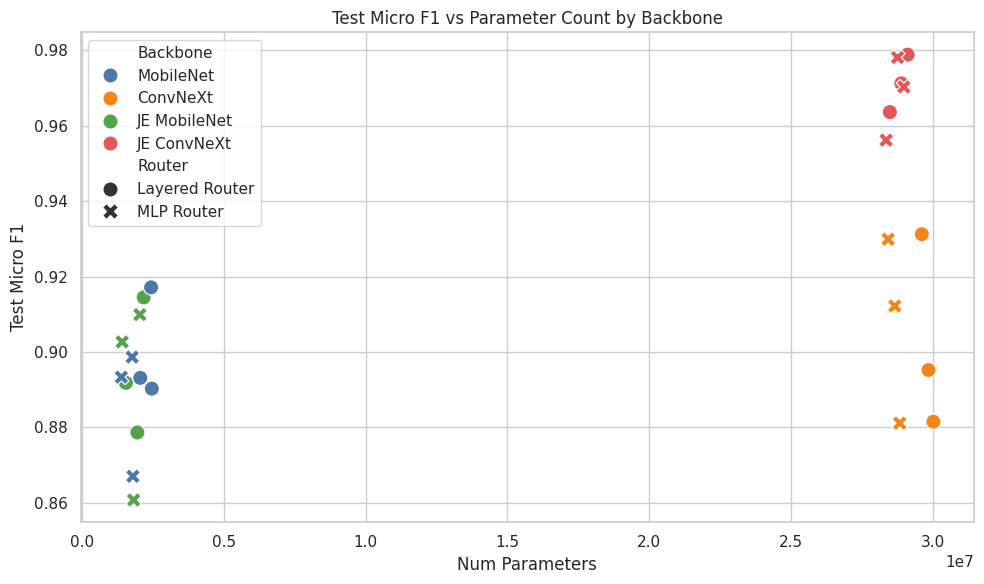

In [15]:
sns.set_theme(style='whitegrid')
palette = {
    'MobileNet': '#4C78A8',
    'ConvNeXt': '#F58518',
    'JE MobileNet': '#54A24B',
    'JE ConvNeXt': '#E45756',
}

backbone_plot_metrics = [
    metric for metric in [
        'Test Micro F1',
        'Test Macro F1',
        'Test Weighted F1',
        'Test ECE',
        'Test Router Entropy',
        'Num Parameters',
    ] if metric in test_results_df.columns
]

if {'Num Parameters', 'Test Micro F1', 'Backbone', 'Router'}.issubset(test_results_df.columns):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=test_results_df,
        x='Num Parameters',
        y='Test Micro F1',
        hue='Backbone',
        style='Router',
        palette=palette,
        s=120,
    )
    plt.title('Test Micro F1 vs Parameter Count by Backbone')
    plt.xlabel('Num Parameters')
    plt.ylabel('Test Micro F1')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_22417/566373640.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = test_results_df.pivot_table(index='Configuration', columns='Backbone', values=metric, aggfunc='mean')


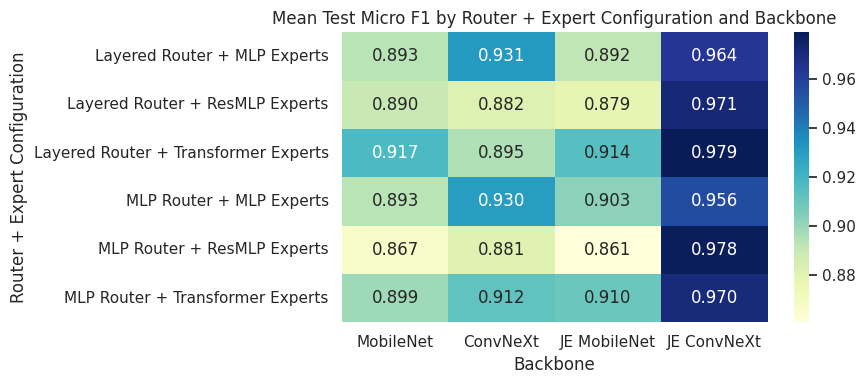

/tmp/ipykernel_22417/566373640.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = test_results_df.pivot_table(index='Configuration', columns='Backbone', values=metric, aggfunc='mean')


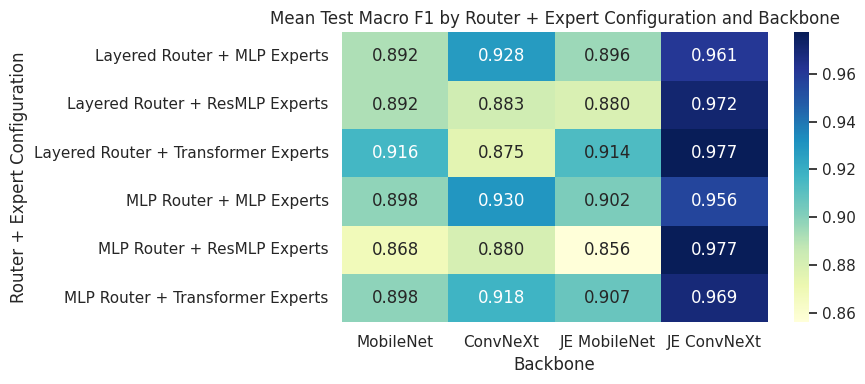

/tmp/ipykernel_22417/566373640.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = test_results_df.pivot_table(index='Configuration', columns='Backbone', values=metric, aggfunc='mean')


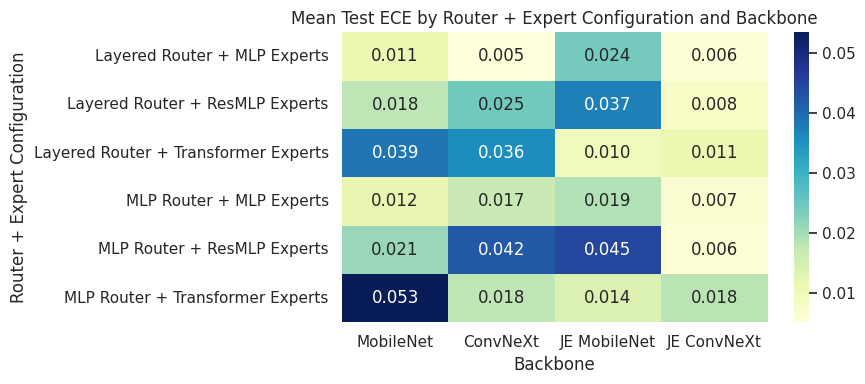

In [16]:
for metric in [name for name in ['Test Micro F1', 'Test Macro F1', 'Test ECE'] if name in test_results_df.columns]:
    pivot = test_results_df.pivot_table(index='Configuration', columns='Backbone', values=metric, aggfunc='mean')
    pivot = pivot.reindex(columns=BACKBONE_ORDER)
    plt.figure(figsize=(9, max(4, len(pivot) * 0.6)))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu')
    plt.title(f'Mean {metric} by Router + Expert Configuration and Backbone')
    plt.xlabel('Backbone')
    plt.ylabel('Router + Expert Configuration')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_22417/1647654669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_results_df, x='Backbone', y=metric, order=BACKBONE_ORDER, palette=palette, fliersize=0)


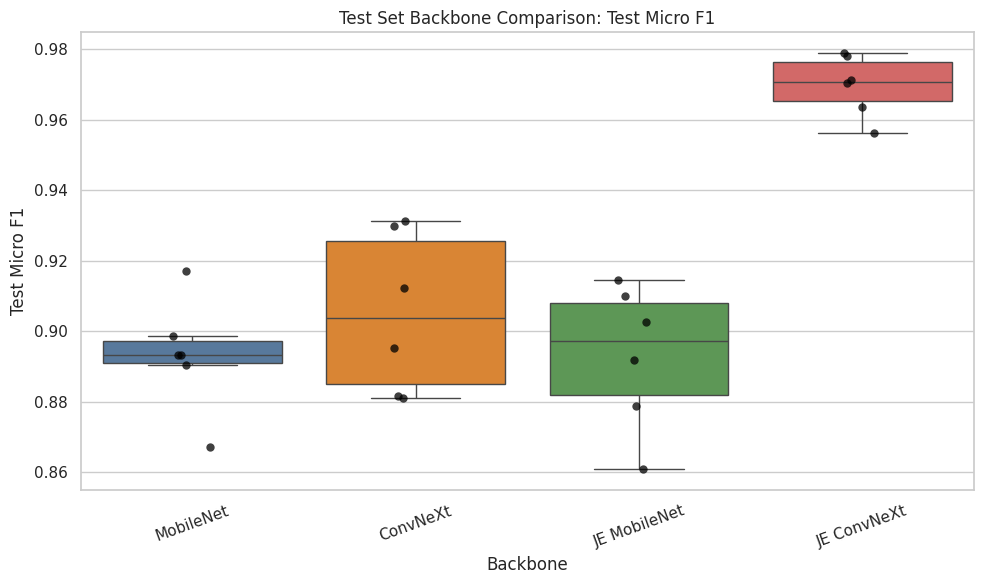

/tmp/ipykernel_22417/1647654669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_results_df, x='Backbone', y=metric, order=BACKBONE_ORDER, palette=palette, fliersize=0)


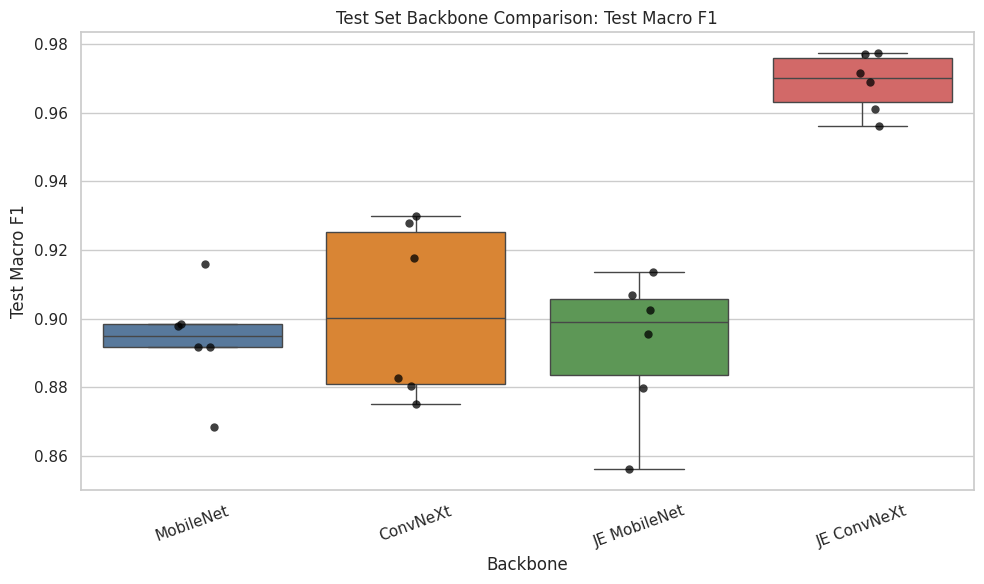

/tmp/ipykernel_22417/1647654669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_results_df, x='Backbone', y=metric, order=BACKBONE_ORDER, palette=palette, fliersize=0)


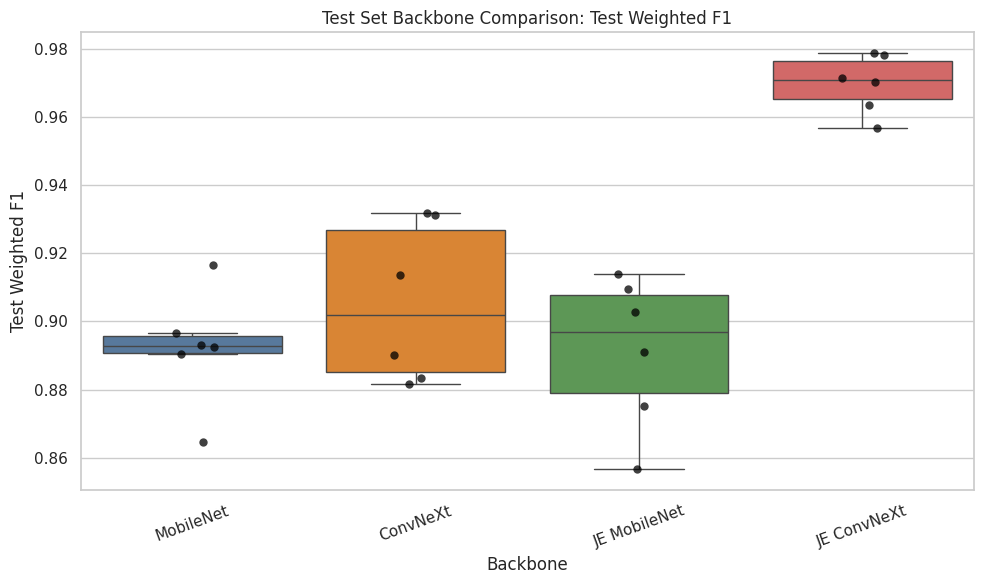

/tmp/ipykernel_22417/1647654669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_results_df, x='Backbone', y=metric, order=BACKBONE_ORDER, palette=palette, fliersize=0)


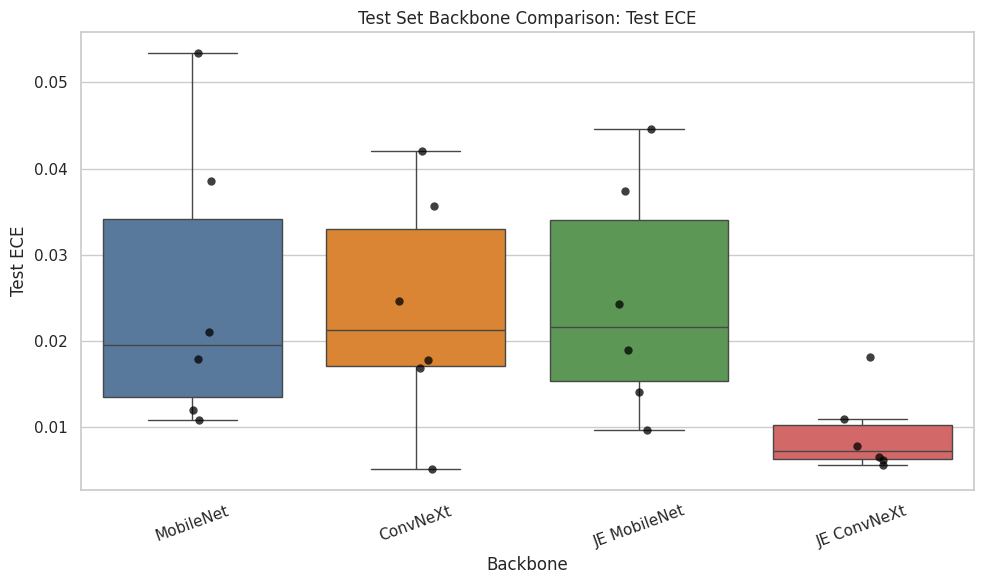

/tmp/ipykernel_22417/1647654669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_results_df, x='Backbone', y=metric, order=BACKBONE_ORDER, palette=palette, fliersize=0)


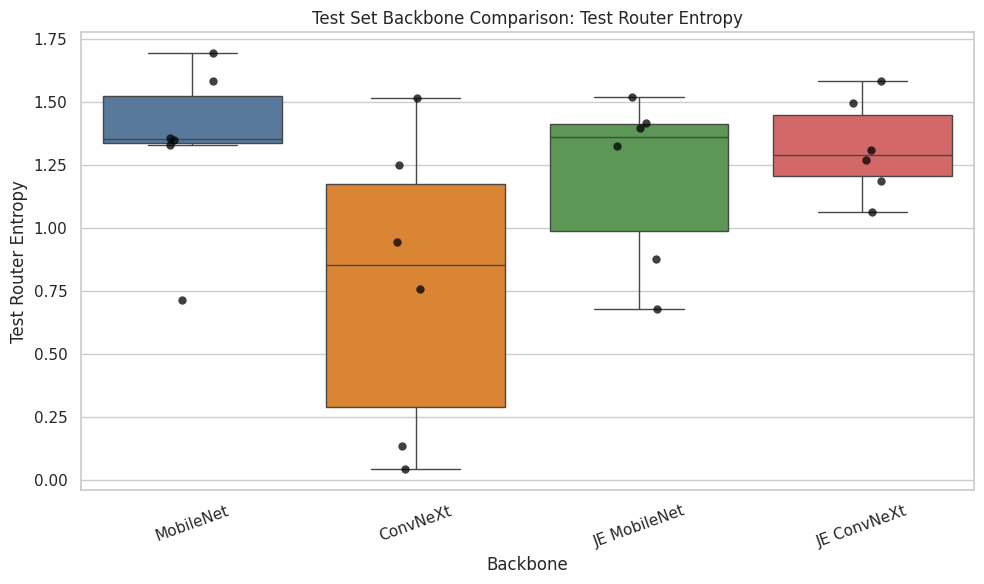

/tmp/ipykernel_22417/1647654669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_results_df, x='Backbone', y=metric, order=BACKBONE_ORDER, palette=palette, fliersize=0)


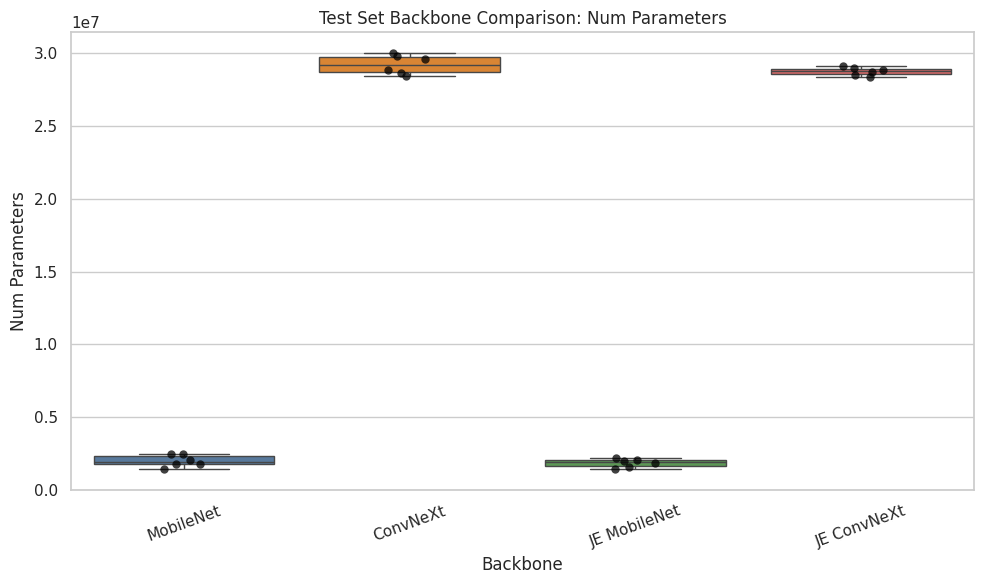

In [17]:
for metric in backbone_plot_metrics:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=test_results_df, x='Backbone', y=metric, order=BACKBONE_ORDER, palette=palette, fliersize=0)
    sns.stripplot(data=test_results_df, x='Backbone', y=metric, order=BACKBONE_ORDER, color='black', alpha=0.75, size=6)
    plt.title(f'Test Set Backbone Comparison: {metric}')
    plt.xlabel('Backbone')
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

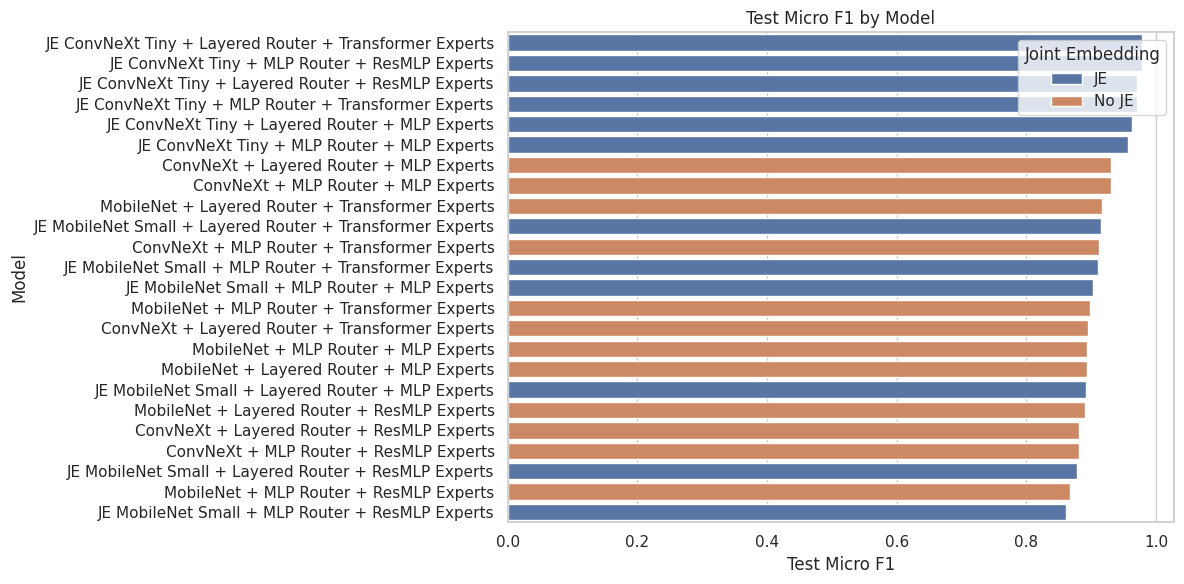

In [18]:
plt.figure(figsize=(12, 6))
plot_df = test_results_df.sort_values('Test Micro F1', ascending=False)
sns.barplot(data=plot_df, x='Test Micro F1', y='Model', hue='Joint Embedding')
plt.title('Test Micro F1 by Model')
plt.xlabel('Test Micro F1')
plt.ylabel('Model')
plt.tight_layout()
plt.show()